# 01_LOG-REG_TF-IDF

**Role.** Classical baseline. Logistic regression over word-level TF-IDF features.

**Research questions.** RQ1 as a classical baseline. RQ2 as the reference model: logistic regression is the one family whose reliance is known exactly from its coefficients, so this notebook also exports `coefficients.csv`, and `tools/validate_shap.py` checks that the SHAP pipeline recovers them before any cross-model attribution claim is made. RQ3 as the classical anchor. RQ4 through its probability artifact.

**Kaggle inputs.**
1. This repository as an input dataset (provides `tools/notebook_kit.py` and the committed split mirror).
2. The output of `00_create_dataset_and_splits` (the `research_foundation/` folder).

**Accelerator.** CPU.

**Outputs.**
- `results_summary/01_LOG-REG_TF-IDF/` and `research_loop/probs/01_LOG-REG_TF-IDF__*`: text-free, copied into the repository.
- `external/01_LOG-REG_TF-IDF/`: weights, per-post predictions and per-post attributions. Uploaded to a Kaggle Dataset and recorded in the run manifest; never committed.

**Protocol.** Configurations and the decision threshold are selected on the validation split. The test split is evaluated once, in section 8. Every attribution comes from one method, SHAP's partition explainer over a word-level text masker, so techniques are comparable.

**What this notebook never shows.** Cell outputs are committed, so no cell prints, displays or plots a post, a row id or a text hash. Outputs are counts, metrics, configurations and word-level tables.

**Responsible use.** A research artifact for studying what classifiers of extremist content rely on. Labels are post-level and features are text only; nothing here supports decisions about people, accounts or communities.

## 1. Bootstrap

Locate and load the shared notebook kit (`tools/notebook_kit.py`), then import the libraries this notebook uses. The first block is identical in every notebook.

In [1]:
import importlib.util
import sys
from pathlib import Path

_kit_candidates = (
    sorted(Path("/kaggle/input").rglob("notebook_kit.py"))
    if Path("/kaggle/input").exists()
    else []
)
_kit_candidates += [p / "tools" / "notebook_kit.py" for p in (Path.cwd(), *Path.cwd().parents)]
_kit_path = next((p for p in _kit_candidates if p.is_file()), None)
if _kit_path is None:
    raise FileNotFoundError(
        "notebook_kit.py not found. Attach the repository (or its tools/ folder) "
        "to this kernel as an input dataset."
    )
_kit_spec = importlib.util.spec_from_file_location("notebook_kit", _kit_path)
nk = importlib.util.module_from_spec(_kit_spec)
sys.modules["notebook_kit"] = nk
_kit_spec.loader.exec_module(nk)

import json
import time
import warnings
from itertools import product

import joblib
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 50)

## 2. Configuration

Everything that defines the run is in `CONFIG`. `nk.bootstrap` refuses a configuration whose technique name is not the filename stem, that names a different split or dataset version, or that switches text previews on. It seeds every random number generator and creates the output folders.

In [2]:
CONFIG = {
    # Identity
    "project_name": "extremism_text_classification_comparison",
    "technique_name": "01_LOG-REG_TF-IDF",
    "role": "classical",
    "in_comparison": True,
    "model_family": "logistic_regression",
    "feature_family": "tfidf_word",
    "dataset_version": "extremism_dataset_clean_v1",
    "split_version": "split_v1_stratified_70_15_15_seed30",
    "random_seed": 30,
    "positive_label": 1,
    "text_normalization_mode": "identity",
    # Configurations compared on validation. Each is scored at the screening
    # threshold; the decision threshold is selected afterwards, once.
    "ablation": {
        "metric": "accuracy",
        "screening_threshold": 0.5,
        "grid": {
            "max_features": [10000, 20000, 50000],
            "ngram_range": [[1, 1], [1, 2], [1, 3]],
            "min_df": [1, 2, 5],
            "max_df": [0.95],
            "sublinear_tf": [True],
            "C": [0.1, 1.0, 3.0, 10.0],
            "class_weight": [None, "balanced"],
        },
    },
    "model": {"solver": "liblinear", "penalty": "l2", "max_iter": 3000},
    "threshold": {"metric": "accuracy"},
    # SHAP partition explainer over a word-level masker (set by the kit).
    # n_posts_per_split None explains every post of the split.
    "explainer": {
        "max_evals": 500,
        "batch_size": 64,
        "seed": 30,
        "n_posts_per_split": None,
        "per_member_runs": False,
        "top_k_display": 50,
    },
    "export_coefficients": True,
    "external": {"save_weights": True, "save_predictions": True},
    "error_analysis": {"include_text_preview": False},
}
ctx = nk.bootstrap(CONFIG)

notebook_kit 1.0.0 (sha256 8a408850f14b55f4)
technique: 01_LOG-REG_TF-IDF   role: classical   run_id: 01_LOG-REG_TF-IDF_20261008T070400Z
working root: /kaggle/working
  python: 3.12.13
  platform: Linux-6.18.48+-x86_64-with-glibc2.35
  numpy: 2.4.6
  pandas: 2.3.3
  sklearn: 1.6.1
  torch: 2.10.0+cu128
  cuda: True
  gpu: Tesla T4
  shap: 0.51.0


## 3. Load foundation and assert the frozen split

Load the processed dataset and the split assignment written by notebook 00. The kit cross-checks the two files against each other and against the manifest, compares the assignment with the committed mirror when the repository is attached, and stops unless the class counts are exactly train 1309/790, validation 281/169, test 280/170 (non-extremist/extremist).

In [3]:
frame, foundation = nk.load_foundation(ctx)
train_df, val_df, test_df = nk.split_frames(frame)

train_texts = train_df["text"].tolist()
y_train = train_df["label"].to_numpy().astype(int)
val_texts = val_df["text"].tolist()

print("Rows per split:", {"train": len(train_df), "validation": len(val_df), "test": len(test_df)})
print("Input file hashes:", json.dumps(foundation["file_sha256_16"], indent=2))

Frozen split verified (total, negative, positive):
  train      (2099, 1309, 790)
  validation (450, 281, 169)
  test       (450, 280, 170)
Committed split mirrors compared: 2
Rows per split: {'train': 2099, 'validation': 450, 'test': 450}
Input file hashes: {
  "processed_dataset": "5d5c8906772ae262",
  "split_assignments": "d80b760f13e3a9f1",
  "dataset_manifest": "0be435840f1a1209"
}


## 4. Features and model

The model is one scikit-learn pipeline: a word-level TF-IDF vectorizer followed by logistic regression. `predict_proba_texts` maps raw strings to P(EXTREMIST) through that pipeline. It is the single entry point used for the validation threshold, the test evaluation and every explainer run, so the model that is explained is exactly the model that predicts.

In [4]:
def expand_grid(grid):
    """Every combination of the grid's values, as a list of dicts."""
    keys = list(grid)
    return [dict(zip(keys, combo)) for combo in product(*(grid[key] for key in keys))]


def build_pipeline(hyperparameters):
    """An unfitted TF-IDF + logistic regression pipeline for one configuration."""
    vectorizer = TfidfVectorizer(
        max_features=hyperparameters["max_features"],
        ngram_range=tuple(hyperparameters["ngram_range"]),
        min_df=hyperparameters["min_df"],
        max_df=hyperparameters["max_df"],
        sublinear_tf=hyperparameters["sublinear_tf"],
        lowercase=True,
        strip_accents=None,
        dtype=np.float32,
    )
    classifier = LogisticRegression(
        C=hyperparameters["C"],
        class_weight=hyperparameters["class_weight"],
        solver=CONFIG["model"]["solver"],
        penalty=CONFIG["model"]["penalty"],
        max_iter=CONFIG["model"]["max_iter"],
        random_state=CONFIG["random_seed"],
    )
    return Pipeline([("tfidf", vectorizer), ("classifier", classifier)])


pipeline = None  # fitted in section 6


def predict_proba_texts(texts):
    """P(EXTREMIST) for a list of raw strings, through the fitted pipeline."""
    return pipeline.predict_proba(list(texts))[:, 1]

## 5. Ablation on validation

Fit every configuration of the grid on the training split and score it on validation at the screening threshold. The configuration with the highest validation accuracy is selected; ties break on validation ROC-AUC, then on configuration id. The test split is not touched.

In [5]:
ablation_configs = expand_grid(CONFIG["ablation"]["grid"])
screening_threshold = CONFIG["ablation"]["screening_threshold"]

ablation_rows = []
ablation_start = time.time()
for number, hyperparameters in enumerate(ablation_configs, start=1):
    candidate = build_pipeline(hyperparameters).fit(train_texts, y_train)
    candidate_prob = candidate.predict_proba(val_texts)[:, 1]
    candidate_metrics = nk.evaluate(ctx, val_df, candidate_prob, screening_threshold, "validation")
    ablation_rows.append(
        nk.ablation_row(ctx, f"config_{number:03d}", hyperparameters, candidate_metrics)
    )

ablation_results = pd.DataFrame(ablation_rows)
best_row = nk.select_best_config(ablation_results, metric=CONFIG["ablation"]["metric"])
best_hyperparameters = ablation_configs[int(best_row["config_id"].split("_")[1]) - 1]

print(f"Configurations compared on validation: {len(ablation_results)}")
print(f"Ablation time: {(time.time() - ablation_start) / 60:.1f} minutes")
print("Selected:", best_row["config_id"], json.dumps(best_hyperparameters))
display(
    ablation_results.sort_values(
        ["validation_accuracy", "validation_roc_auc"], ascending=False
    ).iloc[:10]
)

Configurations compared on validation: 216
Ablation time: 0.6 minutes
Selected: config_103 {"max_features": 20000, "ngram_range": [1, 2], "min_df": 1, "max_df": 0.95, "sublinear_tf": true, "C": 10.0, "class_weight": null}


,technique,config_id,model_family,feature_family,hyperparameter_summary,threshold,validation_accuracy,validation_balanced_accuracy,validation_positive_f1,validation_f1_macro,validation_roc_auc,validation_pr_auc,notes
102,01_LOG-REG_TF-IDF,config_103,logistic_regression,tfidf_word,"{""C"": 10.0, ""class_weight"": null, ""max_df"": 0....",0.5,0.824444,0.801649,0.752351,0.808189,0.888522,0.852689,None
124,01_LOG-REG_TF-IDF,config_125,logistic_regression,tfidf_word,"{""C"": 3.0, ""class_weight"": null, ""max_df"": 0.9...",0.5,0.820000,0.789836,0.736156,0.799781,0.888458,0.853143,None
26,01_LOG-REG_TF-IDF,config_027,logistic_regression,tfidf_word,"{""C"": 1.0, ""class_weight"": null, ""max_df"": 0.9...",0.5,0.820000,0.775685,0.713781,0.791250,0.883004,0.848139,None
170,01_LOG-REG_TF-IDF,config_171,logistic_regression,tfidf_word,"{""C"": 1.0, ""class_weight"": null, ""max_df"": 0.9...",0.5,0.820000,0.772147,0.707581,0.788783,0.880267,0.845747,None
198,01_LOG-REG_TF-IDF,config_199,logistic_regression,tfidf_word,"{""C"": 10.0, ""class_weight"": null, ""max_df"": 0....",0.5,0.817778,0.793952,0.742138,0.800622,0.888353,0.853352,None
98,01_LOG-REG_TF-IDF,config_099,logistic_regression,tfidf_word,"{""C"": 1.0, ""class_weight"": null, ""max_df"": 0.9...",0.5,0.817778,0.771547,0.707143,0.787442,0.883468,0.847799,None
100,01_LOG-REG_TF-IDF,config_101,logistic_regression,tfidf_word,"{""C"": 3.0, ""class_weight"": null, ""max_df"": 0.9...",0.5,0.815556,0.782739,0.726073,0.793522,0.888627,0.852558,None
174,01_LOG-REG_TF-IDF,config_175,logistic_regression,tfidf_word,"{""C"": 10.0, ""class_weight"": null, ""max_df"": 0....",0.5,0.815556,0.792173,0.739812,0.798477,0.886226,0.852762,None
122,01_LOG-REG_TF-IDF,config_123,logistic_regression,tfidf_word,"{""C"": 1.0, ""class_weight"": null, ""max_df"": 0.9...",0.5,0.815556,0.767409,0.700361,0.783567,0.883931,0.849281,None
30,01_LOG-REG_TF-IDF,config_031,logistic_regression,tfidf_word,"{""C"": 10.0, ""class_weight"": null, ""max_df"": 0....",0.5,0.815556,0.792173,0.739812,0.798477,0.883468,0.847142,None


## 6. Final fit

Refit the selected configuration on the training split only. The fitted pipeline is saved under `external/weights/`.

In [6]:
fit_start = time.time()
pipeline = build_pipeline(best_hyperparameters).fit(train_texts, y_train)
fit_seconds = time.time() - fit_start

feature_names = pipeline.named_steps["tfidf"].get_feature_names_out()
if CONFIG["external"]["save_weights"]:
    joblib.dump(pipeline, ctx.external("weights") / "pipeline.joblib")

print("Fitted features:", len(feature_names))
print(f"Fit time: {fit_seconds:.2f}s")

Fitted features: 20000
Fit time: 0.13s


## 7. Threshold on validation

Select the decision threshold on the validation split, from the same grid every technique uses (0.05 to 0.95 in steps of 0.005), maximizing validation accuracy. The kit refuses to select a threshold on any other split. The threshold is now locked.

In [7]:
val_prob = predict_proba_texts(val_texts)
threshold, threshold_sweep = nk.select_threshold(
    val_df, val_prob, metric=CONFIG["threshold"]["metric"]
)
validation_metrics = nk.evaluate(ctx, val_df, val_prob, threshold, "validation")

print(f"Threshold selected on validation ({CONFIG['threshold']['metric']}): {threshold:.3f}")
print(json.dumps(validation_metrics, indent=2))

Threshold selected on validation (accuracy): 0.480
{
  "threshold": 0.48,
  "support": 450,
  "positive_support": 169,
  "negative_support": 281,
  "positive_rate": 0.37555555555555553,
  "accuracy": 0.8266666666666667,
  "balanced_accuracy": 0.8069658236644276,
  "precision_macro": 0.8188080918534719,
  "recall_macro": 0.8069658236644276,
  "f1_macro": 0.8119212962962963,
  "precision_weighted": 0.8250949517040277,
  "recall_weighted": 0.8266666666666667,
  "f1_weighted": 0.8250282921810701,
  "positive_precision": 0.7935483870967742,
  "positive_recall": 0.727810650887574,
  "positive_f1": 0.7592592592592593,
  "roc_auc": 0.8885215523594938,
  "pr_auc": 0.8526891136455288,
  "brier_score": 0.12809231079443356,
  "tn": 249,
  "fp": 32,
  "fn": 46,
  "tp": 123,
  "false_positive_rate": 0.11387900355871886,
  "false_negative_rate": 0.27218934911242604,
  "technique": "01_LOG-REG_TF-IDF",
  "split": "validation"
}


## 8. Single test evaluation

Evaluate the test split once, at the locked threshold. The kit raises if the test split is evaluated a second time in the same run. With 450 test posts, two techniques must differ by about 14 posts before McNemar's test can tell them apart, so this accuracy is a measurement, not a ranking.

In [8]:
test_prob = predict_proba_texts(test_df["text"].tolist())
test_metrics = nk.evaluate(ctx, test_df, test_prob, threshold, "test")

print(json.dumps(test_metrics, indent=2))
display(nk.confusion_matrix_frame(test_metrics))

{
  "threshold": 0.48,
  "support": 450,
  "positive_support": 170,
  "negative_support": 280,
  "positive_rate": 0.37777777777777777,
  "accuracy": 0.8555555555555555,
  "balanced_accuracy": 0.8423319327731092,
  "precision_macro": 0.8483251747504329,
  "recall_macro": 0.8423319327731092,
  "f1_macro": 0.8450831784165117,
  "precision_weighted": 0.854739222238848,
  "recall_weighted": 0.8555555555555555,
  "f1_weighted": 0.8549290030771511,
  "positive_precision": 0.8220858895705522,
  "positive_recall": 0.788235294117647,
  "positive_f1": 0.8048048048048048,
  "roc_auc": 0.913655462184874,
  "pr_auc": 0.8914178604344739,
  "brier_score": 0.10976404692267408,
  "tn": 251,
  "fp": 29,
  "fn": 36,
  "tp": 134,
  "false_positive_rate": 0.10357142857142858,
  "false_negative_rate": 0.21176470588235294,
  "technique": "01_LOG-REG_TF-IDF",
  "split": "test"
}


,actual,predicted,count
0,NON_EXTREMIST,NON_EXTREMIST,251
1,NON_EXTREMIST,EXTREMIST,29
2,EXTREMIST,NON_EXTREMIST,36
3,EXTREMIST,EXTREMIST,134


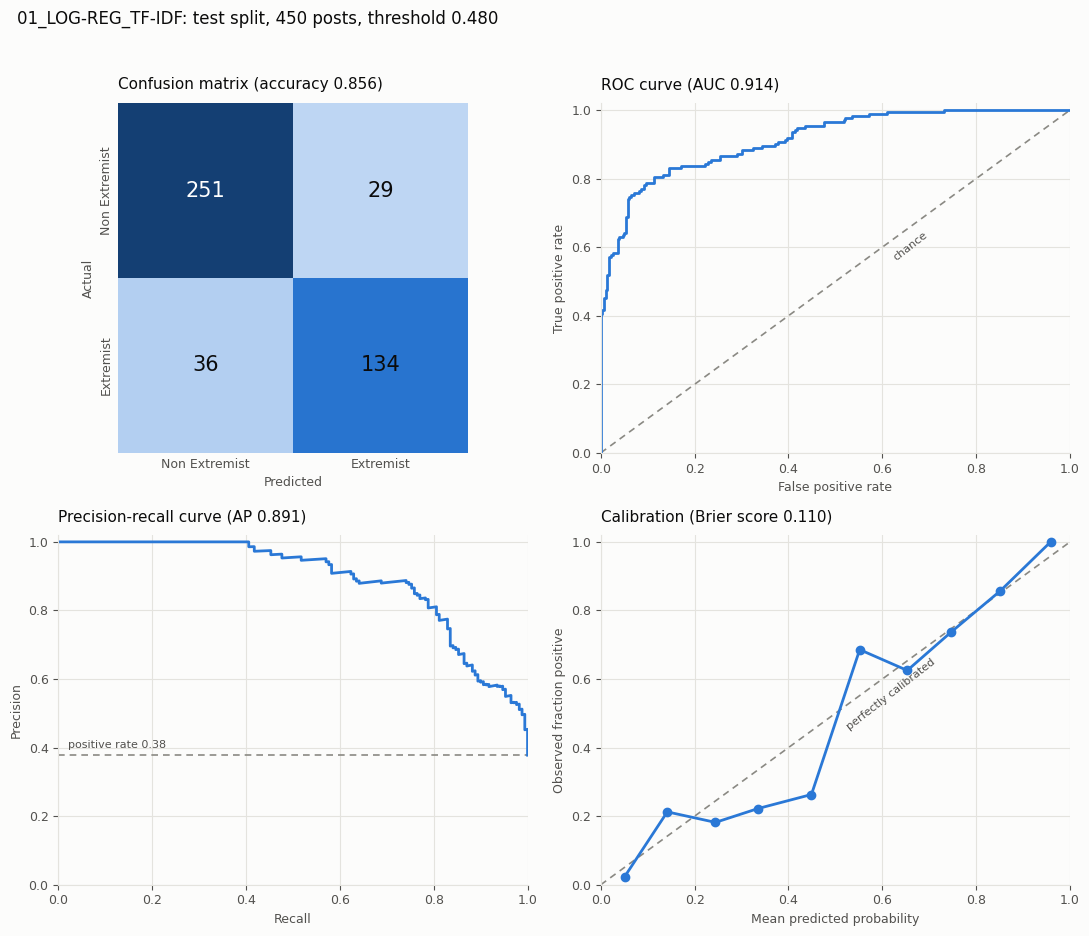

In [9]:
diagnostics_path = nk.plot_diagnostics(ctx, test_df, test_prob, test_metrics)

## 9. Probability artifacts

Write the committed probability artifact: one row per validation and test post with exactly `row_id, split, y_true, y_prob`. Every metric in the result folder, the identity-term false-positive analysis (RQ4) and any later paired test are computed from these files, so a published number can only change when this artifact changes.

In [10]:
probability_paths = nk.export_probabilities(
    ctx,
    val_df,
    val_prob,
    test_df,
    test_prob,
    meta={
        "model_family": CONFIG["model_family"],
        "feature_family": CONFIG["feature_family"],
        "hyperparameters": best_hyperparameters,
        "selected_threshold": threshold,
        "threshold_strategy": nk.THRESHOLD_STRATEGY,
        "threshold_metric": CONFIG["threshold"]["metric"],
    },
)

Probability artifacts written: ['01_LOG-REG_TF-IDF__validation.csv', '01_LOG-REG_TF-IDF__test.csv', '01_LOG-REG_TF-IDF__meta.json']


## 10. Word-level SHAP attribution runs

Explain the fitted model with SHAP's partition explainer over a word-level text masker. The explainer treats the model as a function from text to P(EXTREMIST): it masks words and measures how the probability moves. The same call explains every technique in the repository, which is what makes their attributions comparable.

Each run is reduced to the committed word-level table: for every word, the mean signed and mean absolute attribution over the posts that contain it, and the number of such posts. Two whole-model runs are exported, one over the test split and one over the validation split, so the stability of the result across posts can be measured (RQ3). This notebook explains every post of each split.

The per-post token tables go to `external/` only. The tables shown below are word-level.

In [11]:
explainer_settings = CONFIG["explainer"]
explainer_seed = explainer_settings["seed"]

test_sample = nk.sample_for_explanation(
    test_df, explainer_settings["n_posts_per_split"], explainer_seed
)
test_bundle = nk.explain(ctx, predict_proba_texts, test_sample)
test_attributions = nk.export_attribution_run(
    ctx, test_bundle, f"shap-partition_test_seed{explainer_seed}"
)
display(nk.top_words(test_attributions, explainer_settings["top_k_display"]))

Explained 450 of 450 test posts (max_evals=500, seed=30); 0 had no word tokens.
Attribution run 'shap-partition_test_seed30': 2334 words over 450 test posts (member=None).


,word,mean_abs_attribution,mean_attribution,support
0,nigger,0.398259,0.398259,2
1,shoot,0.312811,0.312811,9
2,see,0.291365,0.291365,10
3,ill,0.290800,0.290800,5
4,islam,0.286021,0.286021,4
5,builders,0.265887,0.265887,1
6,genocide,0.234738,0.234738,14
7,kill,0.233877,0.233877,63
8,rapes,0.231045,0.231045,1
9,resentful,0.222739,0.222739,5


In [12]:
validation_sample = nk.sample_for_explanation(
    val_df, explainer_settings["n_posts_per_split"], explainer_seed
)
validation_bundle = nk.explain(ctx, predict_proba_texts, validation_sample)
validation_attributions = nk.export_attribution_run(
    ctx, validation_bundle, f"shap-partition_validation_seed{explainer_seed}"
)
display(nk.top_words(validation_attributions, explainer_settings["top_k_display"]))

Explained 450 of 450 validation posts (max_evals=500, seed=30); 0 had no word tokens.
Attribution run 'shap-partition_validation_seed30': 2499 words over 450 validation posts (member=None).


,word,mean_abs_attribution,mean_attribution,support
0,coyotes,0.346885,-0.346885,1
1,islam,0.297815,0.297815,3
2,ill,0.290512,0.290512,7
3,genocide,0.261079,0.261079,19
4,builders,0.250794,0.250794,1
5,see,0.247154,0.247154,12
6,shoot,0.245597,0.245597,12
7,ta,0.239465,0.239465,1
8,stuff,0.234221,-0.234221,1
9,boys,0.233674,0.233674,2


**Coefficients.** For logistic regression the reliance on each feature is known exactly: it is the coefficient. `coefficients.csv` holds the coefficient of every single-word feature. `tools/validate_shap.py` compares them with the test run above and requires that the signs agree for the largest coefficients and that the ranks correlate. Features that are n-grams of two or three words have no single-word counterpart in the attribution table, so they are left out and counted.

In [13]:
coefficients = pipeline.named_steps["classifier"].coef_.ravel()
is_single_word = np.array(
    [(" " not in name) and (len(name) <= nk.MAX_WORD_LENGTH) for name in feature_names]
)
coefficients_path = nk.export_coefficients(
    ctx, feature_names[is_single_word], coefficients[is_single_word]
)
print(
    f"Single-word features exported: {int(is_single_word.sum())}; "
    f"multi-word n-gram features left out: {int((~is_single_word).sum())}"
)

Coefficients written: 4692 words.
Single-word features exported: 4692; multi-word n-gram features left out: 15308


## 11. Result folder

Write `results_summary/<technique>/` from the metrics computed above: the selected configuration, validation and test metrics, the confusion matrix, the classification report, the ablation table and the threshold sweep. The kit refuses a folder whose locked threshold differs from the one the metrics were computed at, or whose ablation table has a test column.

In [14]:
best_config = {
    "model_family": CONFIG["model_family"],
    "feature_family": CONFIG["feature_family"],
    "hyperparameters": {**best_hyperparameters, **CONFIG["model"]},
    "threshold_strategy": nk.THRESHOLD_STRATEGY,
    "threshold_metric": CONFIG["threshold"]["metric"],
    "selected_threshold": threshold,
    "selected_config_id": best_row["config_id"],
    "selection_rule": (
        "highest validation accuracy at the screening threshold; ties on validation ROC-AUC, "
        "then configuration id"
    ),
    "n_validation_candidates": int(len(ablation_results)),
    "validation_uses": ["config_selection", "threshold"],
    "n_fitted_features": int(len(feature_names)),
    "fit_seconds": fit_seconds,
}
results_folder = nk.export_results_folder(
    ctx, best_config, validation_metrics, test_metrics, ablation_results, threshold_sweep
)

Result folder written: /kaggle/working/results_summary/01_LOG-REG_TF-IDF (7 files)


## 12. External assets

Files that are too large for git or that hold dataset text are written under `external/`: the fitted model, the per-post predictions a reviewer reads, and the per-post attribution tables. The table below is all that is shown here: test outcomes counted by confidence.

In [15]:
if CONFIG["external"]["save_predictions"]:
    nk.export_external_predictions(ctx, val_df, val_prob, test_df, test_prob, threshold)

display(nk.error_counts(test_df, test_prob, threshold))

Per-post predictions written to external/ (hold dataset text; not committed).


,outcome,confidence,count
0,false_negative,0.5-0.6,4
1,false_negative,0.6-0.8,12
2,false_negative,0.8-1.0,20
3,false_positive,0.5-0.6,14
4,false_positive,0.6-0.8,11
5,false_positive,0.8-1.0,4
6,true_negative,0.5-0.6,11
7,true_negative,0.6-0.8,50
8,true_negative,0.8-1.0,190
9,true_positive,0.5-0.6,25


## 13. Interpretation

This section is written before the run and states how to read the outputs. Numbers are not copied here; they live in the result folder and the rendered tables.

**Reading the outputs.** The word tables in section 10 rank words by mean absolute attribution; the signed mean says whether a word pushes toward EXTREMIST (positive) or away from it. For this model they should agree with the coefficients, and `tools/validate_shap.py` tests that. A failure there means the explainer configuration is wrong and must be fixed before any other technique's attributions are read.

**False positives and false negatives.** The outcome table in section 12 counts each error type by confidence. High-confidence false positives are the cases RQ4 examines: `tools/identity_fpr.py` measures whether they concentrate on non-extremist posts that mention an identity term. Review of individual errors uses the per-post files in `external/`, never a cell output.

**Limitations.**
- Coefficients are exported for single-word features only. When the selected configuration uses bigrams or trigrams, part of the model's weight sits in features the word-level table can only show through their component words.
- Labels are post-level and features are text only. The model detects extremist content in a post. It does not detect accounts, intent or radicalization over time.
- One dataset and one 450-post test split. A gap of fewer than about 14 test posts between two techniques is not a detectable difference.
- SHAP attributions describe what moves this model's probability when words are masked. Masked text is unlike real posts, and an attribution is not a causal claim about language.
- Lexicon categories (extremist framing, identity term, slur, topical) are assigned afterwards by `tools/categorize_attributions.py`; no category is assigned in this notebook.

## 14. Package outputs

Inventory the external files with their hashes, check that nothing text-bearing sits in the committed tree, and zip the files that go into the repository. The zip unpacks at the repository root.

**After the run.**
1. Unzip `<technique>_repo_files.zip` at the repository root.
2. Upload `external/<technique>/` to a Kaggle Dataset, then record it: `tools/run_manifest.py init`, then `add-assets-from --file external_assets.json`.
3. Run `tools/validate_results_folder.py --all`, `tools/identity_fpr.py`, `tools/categorize_attributions.py`, `tools/compare_reliance.py`, then `tools/render_tables.py --write`.
4. Before committing this notebook with its outputs, run `tools/check_notebook.py --notebook <file>` and `tools/scan_text_leakage.py`.

In [16]:
nk.finalize(ctx)

Repository files (15), zipped to 01_LOG-REG_TF-IDF_repo_files.zip:
  results_summary/01_LOG-REG_TF-IDF/ablation_results.csv
  results_summary/01_LOG-REG_TF-IDF/attributions/coefficients.csv
  results_summary/01_LOG-REG_TF-IDF/attributions/shap-partition_test_seed30.csv
  results_summary/01_LOG-REG_TF-IDF/attributions/shap-partition_test_seed30.json
  results_summary/01_LOG-REG_TF-IDF/attributions/shap-partition_validation_seed30.csv
  results_summary/01_LOG-REG_TF-IDF/attributions/shap-partition_validation_seed30.json
  results_summary/01_LOG-REG_TF-IDF/best_config.json
  results_summary/01_LOG-REG_TF-IDF/classification_report_test.json
  results_summary/01_LOG-REG_TF-IDF/confusion_matrix_test.csv
  results_summary/01_LOG-REG_TF-IDF/metrics_test.json
  results_summary/01_LOG-REG_TF-IDF/metrics_validation.json
  results_summary/01_LOG-REG_TF-IDF/threshold_sweep_validation.csv
  research_loop/probs/01_LOG-REG_TF-IDF__meta.json
  research_loop/probs/01_LOG-REG_TF-IDF__test.csv
  research_

PosixPath('/kaggle/working/01_LOG-REG_TF-IDF_repo_files.zip')